# Big Data Analytics and Text Minig Project

### Tommaso Bergonzoni & Ivo Rimbaldi

# Motivation

TODO: Explain the project, the three tasks and the metrics we'll use

# Set up

Installing right versions of libraries

In [1]:
!pip install -q --upgrade "pillow<11.0.0" transformers>=4.45.0 accelerate torchao scikit-learn tqdm chess cairosvg python-Levenshtein datasets peft huggingface_hub

Importing libraries

In [2]:
# Standard library imports
from collections import Counter
import gc
import json
import os
from pathlib import Path
import shutil
import subprocess
import sys

# Third-party library imports
from datasets import load_dataset, Dataset
from functools import partial
from huggingface_hub import HfApi, notebook_login, snapshot_download
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from peft import LoraConfig, PeftModel, TaskType, get_peft_model
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
from tqdm import tqdm
from transformers import (
    AutoModelForImageTextToText,
    AutoProcessor,
    Trainer,
    TrainingArguments,
    set_seed
)



Environment set up : github repo cloning

In [3]:
# Project configuration dictionary
CONFIG = {
    "colab": True,
    "branch": "main",
    "repo_name": "BigDataAndTextMiningProject",
    "repo_owner": "Aivon99",
    "repo_dir": "/content/BigDataAndTextMiningProject",
}

# Setup repository path and Hugging Face name
repo_root = Path(CONFIG["repo_dir"])

if CONFIG["colab"]:
    # If the repository folder already exists, reference it safely
    if repo_root.exists():
        print(f"Repository directory already exists at: {repo_root}")
    else:
        auth_url = "https://"
        repo_url = f"{auth_url}github.com/{CONFIG['repo_owner']}/{CONFIG['repo_name']}.git"

        print(f"Cloning repository from {repo_url}...")
        result = subprocess.run(
            ["git", "clone", "--single-branch", "--branch", CONFIG["branch"], repo_url, str(repo_root)],
            capture_output=True, text=True
        )
        assert result.returncode == 0, f"Git clone failed: {result.stderr}"
else:
    repo_root = Path(".").resolve().parent.parent


print(f"Setup Complete. REPO_ROOT: {repo_root}")

# Check GPU and device availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Cloning repository from https://github.com/Aivon99/BigDataAndTextMiningProject.git...
Setup Complete. REPO_ROOT: /content/BigDataAndTextMiningProject
Using device: cuda
GPU: NVIDIA A100-SXM4-40GB


Environment setup: importing functions/classes from different files inside the repo

In [4]:
# Configure system paths for absolute module imports
sys.path.insert(0, str(repo_root))
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root / "src" / "data"))
sys.path.insert(0, str(repo_root / "src" / "eval"))

# Import custom project modules cleanly
from data.generation import (
    build_sample,
    generate_dataset,
)

from data.utilities import (
    load_lichess_csv,
    upload_dataset_to_hub,
    authenticate_hf,
    set_all_seeds
)

from eval.utilities import (
   calculate_fen_exact_match,
   calculate_levenshtein_metrics,
   calculate_square_by_square_accuracy,
   evaluate_chessboard_model_task_1,
   evaluate_chessboard_model_task_2,
   evaluate_chessboard_model_task_3,
   preprocess_function,
   get_patch_reordering_indices,
   reorder_chessboard_image,
   finetune_and_push_chessboard_model,
   Qwen35VisionDataCollator
)

print("All custom modules and eval utilities imported successfully!")

All custom modules and eval utilities imported successfully!


Reproducibility & Random Seed Setup (Using function **set_all_seeds()** defined in *src/data/utilities.py*

In [5]:
RANDOM_SEED = 42
set_all_seeds(RANDOM_SEED)

All seeds successfully set to 42 for full pipeline reproducibility.


### Hugging Face Considerations & Permissions

The official organization used during the development of this project is **`bdatm-project`**.

* **Recreating the Project from Zero:** If your goal is to fully retrain and recreate our project, you must define your own organization or user namespace, as guest users lack write permissions to modify the official organization's repositories.
* **Downloading Results Only:** If you only wish to download and evaluate our pre-computed results and models, you can safely use our public repository. However, you should skip or avoid executing cells that attempt to push weights or data to the hub, as lack of permissions will cause them to fail.

To run the pipeline on your own space, simply update the variable below with your personal Hugging Face organization or username:

In [6]:
# Set your target Hugging Face organization or username
# (Change this to your own namespace if you plan to run training and push models/results)
ORGANIZATION_NAME = "bdatm-project"

# Dataset

### Dataset Creation

We use "lichess_db_puzzle.csv" dataset as a baseline for the creation of our dataset

Loading dataset

In [7]:
csv_path = Path("lichess_db_puzzle.csv")
zst_path = Path("lichess_db_puzzle.csv.zst")

if not csv_path.exists():
  # 1. Ensure zstd system tool is installed in Colab
  if shutil.which("zstd") is None and shutil.which("unzstd") is None:
    print("Installing zstd decompression tool...")
    !apt-get update -qq && apt-get install -y zstd -qq

  # 2. Download compressed dataset if not present
  if not zst_path.exists():
    print("Downloading Lichess puzzles database ...")
    !wget -q --show-progress https://database.lichess.org/lichess_db_puzzle.csv.zst

  # 3. Decompress to CSV and remove the archive
  print("Decompressing archive )...")
  !unzstd -f --rm lichess_db_puzzle.csv.zst -o lichess_db_puzzle.csv

  # 4. Clean up any leftover duplicate downloads
  !rm -f lichess_db_puzzle.csv.zst.*

  print("Decompression complete!")
else:
  print(f"'{csv_path}' already exists.")

Installing zstd decompression tool...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package zstd.
(Reading database ... 122579 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
lichess_db_puzzle.c 100%[===================>] 290.28M  6.38MB/s    in 44s     
Decompressing archive )...
lichess_db_puzzle.csv.zst: 1129374135 bytes 
Decompression complete!


Defining constants to set the size of the datasets:

**Testing and Debugging Note**

If you want to quickly test the notebook in a reasonable amount of time without running the full pipeline, you can adjust the sampling variables below.

> **Important Note:** `MAX_SAMPLES` must be slightly greater than `N_WHITE_BLACK * 2` (for instance, 2000 white-to-move samples plus 2000 black-to-move samples equals 4000 total samples).

In [8]:
#TO MODIFY!!
MAX_SAMPLES = 100
N_WHITE_BLACK = 20

#A good configuration to test the whole notebook (dataset generation / finetuning / evaluation ) in a reasonable time could be:
#MAX_SAMPLES = 100
#N_WHITE_BLACK = 20

Loading the correct number of samples (black and white moves)

In [9]:
df_raw = load_lichess_csv(csv_path=csv_path, max_samples=MAX_SAMPLES)

# Extract the active turn from FEN for balancing ('w' or 'b')
df_raw["turn"] = df_raw["FEN"].apply(
    lambda f: f.split(" ")[1] if len(f.split(" ")) > 1 else "w"
)

# Sample black and white moves as defined by constant N_WHITE_BLACK
df_white = df_raw[df_raw["turn"] == "w"].sample(n=N_WHITE_BLACK, random_state=42)
df_black = df_raw[df_raw["turn"] == "b"].sample(n=N_WHITE_BLACK, random_state=42)

df_balanced = (
    pd.concat([df_white, df_black])
    .sample(frac=1.0, random_state=42)
    .reset_index(drop=True)
)

print(f"Balanced dataset loaded: {len(df_balanced)} total puzzles")
print(df_balanced["turn"].value_counts())

Balanced dataset loaded: 40 total puzzles
turn
w    20
b    20
Name: count, dtype: int64


Stratified split : 80% (train) - 10% (val) - 10% (test)

In [10]:
train_df, temp_df = train_test_split(
    df_balanced, test_size=0.20, random_state=42, stratify=df_balanced["turn"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["turn"]
)

splits = {
    "train": train_df,
    "validation": val_df,
    "test": test_df
}

print(f"Split sizes: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

Split sizes: Train=32, Val=4, Test=4


Creating dataset using the function ***generate_dataset()*** defined in *src/data/generation.py*. This function generates the dataset for each of the three task depending on the argument passed in it.

In [11]:
tasks = ["task1", "task2", "task3"]

for task in tasks:
    print(f"\n==================== GENERATING {task.upper()} ====================")
    for split_name, split_df in splits.items():
        output_dir = f"dataset_{task}/{split_name}"

        # Remove existing directory and its contents if present
        #if os.path.exists(output_dir):
            #shutil.rmtree(output_dir)
        os.makedirs(output_dir, exist_ok=True)


        generate_dataset(
            df=split_df,
            task=task,
            output_dir=output_dir,
            image_size=512
        )

print("\nAll 3 datasets have been successfully generated!")


==================== GENERATING TASK1 ====================


Generating task1: 100%|██████████| 4/4 [00:00<00:00, 11.58it/s]



==================== GENERATING TASK2 ====================


Generating task2: 100%|██████████| 4/4 [00:00<00:00, 12.03it/s]



==================== GENERATING TASK3 ====================


Generating task3: 100%|██████████| 4/4 [00:00<00:00,  5.92it/s]


All 3 datasets have been successfully generated!


### Dataset Displaying and Uploading

Displaying datasets statistics

In [12]:
splits = ["train", "validation", "test"]
stats = []

print("=== DATASET STATISTICS ===")
for task in tasks:
    for split in splits:
        split_dir = Path(f"dataset_{task}/{split}")
        if not split_dir.exists():
            stats.append({
                "Task": task,
                "Split": split,
                "Samples": 0,
                "Total Size (MB)": 0.0,
            })
            continue

        sample_folders = [f for f in split_dir.iterdir() if f.is_dir()]
        total_bytes = sum(
            f.stat().st_size for f in split_dir.rglob("*") if f.is_file()
        )
        total_mb = total_bytes / (1024 * 1024)

        stats.append({
            "Task": task,
            "Split": split,
            "Samples": len(sample_folders),
            "Total Size (MB)": round(total_mb, 2),
        })

stats_df = pd.DataFrame(stats)
display(stats_df)

=== DATASET STATISTICS ===


,Task,Split,Samples,Total Size (MB)
0,task1,train,32,1.21
1,task1,validation,4,0.18
2,task1,test,4,0.16
3,task2,train,32,1.19
4,task2,validation,4,0.18
5,task2,test,4,0.15
6,task3,train,32,2.38
7,task3,validation,4,0.35
8,task3,test,4,0.31


Displaying metadata verification check

In [13]:
print("\n=== INTEGRITY & SCHEMA VERIFICATION ===")
for task in tasks:
    split_dir = Path(f"dataset_{task}/train")
    if not split_dir.exists():
        continue

    jsonl_path = split_dir / "metadata.jsonl"
    if not jsonl_path.exists():
        print(f"[{task.upper()}] metadata.jsonl not found.")
        continue

    # Pick the first line
    with open(jsonl_path, "r", encoding="utf-8") as f:
        first_line = f.readline()
        meta = json.loads(first_line)

    sample_id = meta.get("sample_id")
    sample_dir = split_dir / sample_id

    # Check images
    file_names = [meta.get("file_name")]
    if meta.get("file_name_t1"):
        file_names.append(meta.get("file_name_t1"))

    missing_images = [
        fn for fn in file_names if fn and not (split_dir / fn).exists()
    ]

    print(f"\nTask: {task.upper()} ({sample_id})")
    print(f"  - Puzzle ID:      {meta.get('puzzle_id')}")
    print(f"  - FEN:            {meta.get('fen')}")
    print(f"  - Target:         {meta.get('target')}")
    print(f"  - Expected Files: {file_names}")
    print(
        f"  - Status:         {'[OK]' if not missing_images else '[MISSING FILES: ' + str(missing_images) + ']'}"
    )




=== INTEGRITY & SCHEMA VERIFICATION ===

Task: TASK1 (sample_000000)
  - Puzzle ID:      2GDeK
  - FEN:            r1b2rk1/ppRq3p/3p2p1/3PPp2/8/3B1NP1/2Q2K1P/8 b - - 1 30
  - Target:         r1b2rk1/ppRq3p/3p2p1/3PPp2/8/3B1NP1/2Q2K1P/8 b - - 1 30
  - Expected Files: ['sample_000000/board.png']
  - Status:         [OK]

Task: TASK2 (sample_000000)
  - Puzzle ID:      2GDeK
  - FEN:            r1b2rk1/ppRq3p/3p2p1/3PPp2/8/3B1NP1/2Q2K1P/8 b - - 1 30
  - Target:         Qe8
  - Expected Files: ['sample_000000/board.png']
  - Status:         [OK]

Task: TASK3 (sample_000000)
  - Puzzle ID:      2GDeK
  - FEN:            r1b2rk1/ppRq3p/3p2p1/3PPp2/8/3B1NP1/2Q2K1P/8 b - - 1 30
  - Target:         Qe8
  - Expected Files: ['sample_000000/board_t.png', 'sample_000000/board_t_plus_1.png']
  - Status:         [OK]


Displaying visual samples for the three tasks


=== VISUAL SAMPLE INSPECTION ===


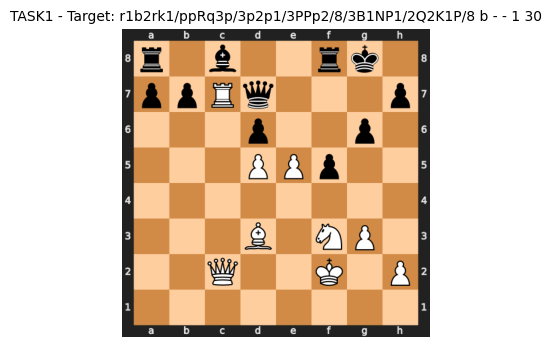

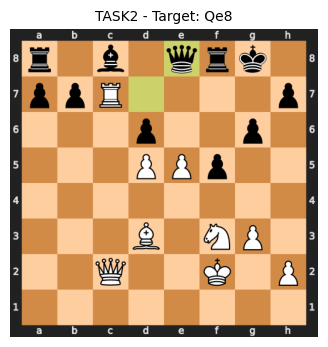

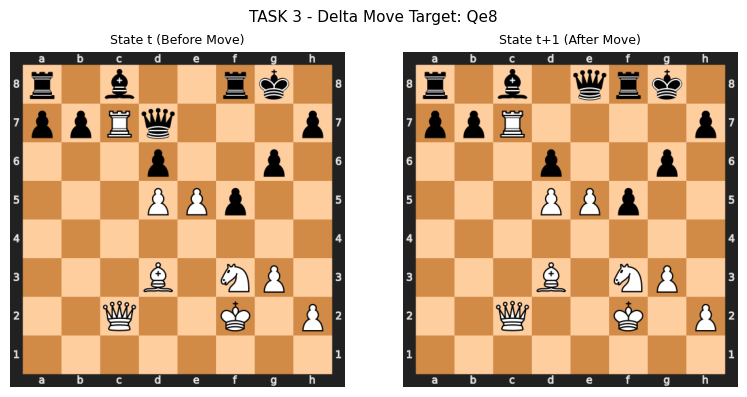

In [14]:
print("\n=== VISUAL SAMPLE INSPECTION ===")

for task in tasks:
    split_dir = Path(f"dataset_{task}/train")
    jsonl_path = split_dir / "metadata.jsonl"
    if not jsonl_path.exists():
        continue

    # read first record form the json
    with open(jsonl_path, "r", encoding="utf-8") as f:
        meta = json.loads(f.readline())

    sample_id = meta.get("sample_id")
    sample_dir = split_dir / sample_id

    if task in ["task1", "task2"]:
        # Single image visualization
        img_path = split_dir / meta["file_name"]
        img = Image.open(img_path)

        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{task.upper()} - Target: {meta['target']}", fontsize=10)
        plt.show()

    elif task == "task3":
        # Dual-image pair visualization (State t and State t+1 side-by-side)
        img_t_path = split_dir / meta["file_name"]
        img_t1_path = split_dir / meta["file_name_t1"]

        img_t = Image.open(img_t_path)
        img_t1 = Image.open(img_t1_path)

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(img_t)
        axes[0].set_title("State t (Before Move)", fontsize=9)
        axes[0].axis("off")

        axes[1].imshow(img_t1)
        axes[1].set_title("State t+1 (After Move)", fontsize=9)
        axes[1].axis("off")

        fig.suptitle(
            f"TASK 3 - Delta Move Target: {meta['target']}", fontsize=11, y=0.98
        )
        plt.tight_layout()
        plt.show()


Upload each dataset to Hugging Face

In [16]:
#Autenthication on Hugging Face
notebook_login()

In [17]:
api = HfApi()

print("\n==================== UPLOADING TO HUGGING FACE ====================\\")
for task in tasks:
  local_directory = f"dataset_{task}"
  remote_dataset_name = f"dataset_{task}"

  repo_id = f"{ORGANIZATION_NAME}/{remote_dataset_name}"

  print(f"Uploading folder {local_directory} to {repo_id} ...")

  api.upload_folder(
      folder_path=local_directory,
      repo_id=repo_id,
      repo_type="dataset",
      delete_patterns="**/metadata.json",
      commit_message=(
          f"Remove nested metadata.json and sync clean structure for {remote_dataset_name}"
      ),
  )

print("\nAll datasets have been synchronized successfully to Hugging Face!")


==================== UPLOADING TO HUGGING FACE ====================\
Uploading folder dataset_task1 to bdatm-project/dataset_task1 ...


No files have been modified since last commit. Skipping to prevent empty commit.


Uploading folder dataset_task2 to bdatm-project/dataset_task2 ...


No files have been modified since last commit. Skipping to prevent empty commit.


Uploading folder dataset_task3 to bdatm-project/dataset_task3 ...


No files have been modified since last commit. Skipping to prevent empty commit.



All datasets have been synchronized successfully to Hugging Face!


# Evaluation

### Dataset

Dowloading datasets for all three tasks from Hugging Face

In [18]:
# 1. Verify Authentication to Hugging Face once for all datasets
print("Verifying Authentication to Hugging Face...")
notebook_login()

# 2. Load Dataset Task 1
print("\n--- Processing Dataset Task 1 ---")
dataset_name_1 = "bdatm-project/dataset_task1"
print(f"Downloading dataset '{dataset_name_1}'...")

dataset_task1 = load_dataset(dataset_name_1)

print("Dataset Task 1 loaded successfully!")
print(dataset_task1)
print("Structure sample of train split - Task 1:", dataset_task1["train"][0])


# 3. Load Dataset Task 2
print("\n--- Processing Dataset Task 2 ---")
dataset_name_2 = "bdatm-project/dataset_task2"
print(f"Downloading dataset '{dataset_name_2}'...")

dataset_task2 = load_dataset(dataset_name_2)

print("Dataset Task 2 loaded successfully!")
print(dataset_task2)
print("Structure sample of train split - Task 2:", dataset_task2["train"][0])


# 4. Download Snapshot and Load Dataset Task 3
print("\n--- Processing Dataset Task 3 ---")
dataset_name_3 = "bdatm-project/dataset_task3"

# Download the entire dataset repository locally into a distinct folder
print("Downloading dataset snapshot locally...")
local_data_dir = snapshot_download(
    repo_id=dataset_name_3,
    repo_type="dataset",
    local_dir="./my_dataset_files_task3"
)

# Load the dataset structure via load_dataset
print(f"Loading dataset '{dataset_name_3}'...")
dataset_task3 = load_dataset(dataset_name_3)

# Loop through each split (train, validation, test) and map the second frame correctly
print("Mapping the dataset across splits to include image_t1...")
for split_name in dataset_task3.keys():

    def add_second_frame(example):
        # Build the path incorporating the split folder and file name
        file_path = os.path.join("./my_dataset_files_task3", split_name, example["file_name_t1"])
        example["image_t1"] = Image.open(file_path).convert("RGB")
        return example

    dataset_task3[split_name] = dataset_task3[split_name].map(add_second_frame)

print("Dataset Task 3 loaded and mapped successfully!")
print(dataset_task3)
print("Structure sample of train split - Task 3:", dataset_task3["train"][0])

print("\nAll three datasets have been successfully downloaded, loaded, and processed!")

Verifying Authentication to Hugging Face...

--- Processing Dataset Task 1 ---


Resolving data files:   0%|          | 0/33 [00:00<?, ?it/s]

train/sample_000013/board.png: reconstructing file:   0%|          |  0.00B / 27.1kB            

train/sample_000010/board.png: reconstructing file:   0%|          |  0.00B / 47.2kB            

train/sample_000012/board.png: reconstructing file:   0%|          |  0.00B / 28.6kB            

...

Mapping the dataset across splits to include image_t1...


Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

Dataset Task 3 loaded and mapped successfully!
DatasetDict({
    train: Dataset({
        features: ['sample_id', 'puzzle_id', 'task', 'fen', 'prompt', 'target', 'image', 'file_name_t1', 'image_t1'],
        num_rows: 32
    })
    validation: Dataset({
        features: ['sample_id', 'puzzle_id', 'task', 'fen', 'prompt', 'target', 'image', 'file_name_t1', 'image_t1'],
        num_rows: 4
    })
    test: Dataset({
        features: ['sample_id', 'puzzle_id', 'task', 'fen', 'prompt', 'target', 'image', 'file_name_t1', 'image_t1'],
        num_rows: 4
    })
})
Structure sample of train split - Task 3: {'sample_id': 'sample_000000', 'puzzle_id': '2GDeK', 'task': 'task3', 'fen': 'r1b2rk1/ppRq3p/3p2p1/3PPp2/8/3B1NP1/2Q2K1P/8 b - - 1 30', 'prompt': 'You are a specialized model for chessboard temporal reasoning.\nYour goal is to identify the move that transitioned the chessboard from State t to State t+1.\nInput:\n- Frame 1: Chessboard state at time t.\n- Frame 2: Chessboard state at time t

## Model - Vanilla

TODO: description of the model, reasons why we used it

In [19]:
model_id = "Qwen/Qwen3.5-0.8B"
print(f"Loading model {model_id}...")

model_vanilla = AutoModelForImageTextToText.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(model_id)
print("model and Processor loaded correctly!")

Loading model Qwen/Qwen3.5-0.8B...


config.json:   0%|          | 0.00/2.91k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/50.9k [00:00<?, ?B/s]

model.safetensors-00001-of-00001.safeten(…): reconstructing file:   0%|          |  0.00B / 1.75GB            

...

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 12.8MB            

tokenizer.json: downloading bytes:           |  0.00B            

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

model and Processor loaded correctly!


Testing model on a single sample for each task


       PROCESSING: TASK 1 (IMAGE-TO-FEN)
**Sample ID:** sample_000000
**Task Prompt:** 
You are a specialized model for chessboard understanding.
Your goal is to extract the exact board state from the provided chessboard image.
Input:
- Board Image: The visual representation of the chessboard.
Output Format:
Return only the valid FEN string representing the position of all pieces on the board.
**Ground Truth (Target):** 4Q3/p5pp/2p1p1k1/2Pp4/3n2B1/8/P2q2rP/5R1K b - - 5 28

**Visual Input:** Single board image


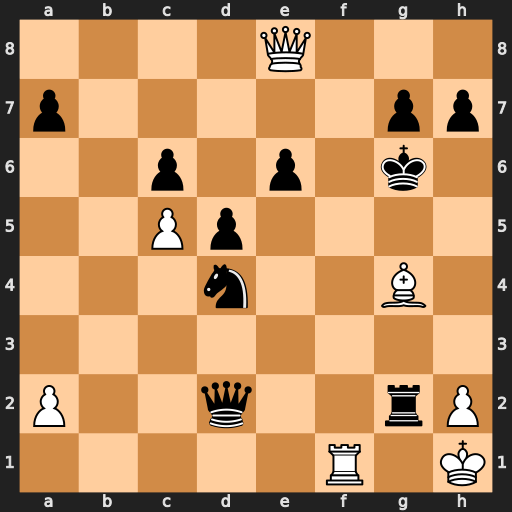

Generating zero-shot prediction for Task 1 (Image-to-FEN)...

--- RESULT ---
**Predicted Output:** a1b2c3d4e5f6g7h8
8h7g7e8
7d6c5b4a3
4e3d2c1b0
1f2g1h0
0d0e0f0g0h0
0a0b0c0d0e0f0g0h0
0a0b0c0d0e0f0g0h0
**Real Target (GT):**  4Q3/p5pp/2p1p1k1/2Pp4/3n2B1/8/P2q2rP/5R1K b - - 5 28
----------------------------------------------


       PROCESSING: TASK 2 (MOVE PREDICTION)
**Sample ID:** sample_000000
**Task Prompt:** 
You are a specialized model for chessboard understanding.
Your goal is to predict the last move played on the board based on the highlighted squares.
Input:
- Board Image: The visual representation with the last move highlighted.
Output Format:
Return only the move in Standard Algebraic Notation (SAN).
**Ground Truth (Target):** Kg5

**Visual Input:** Single board image


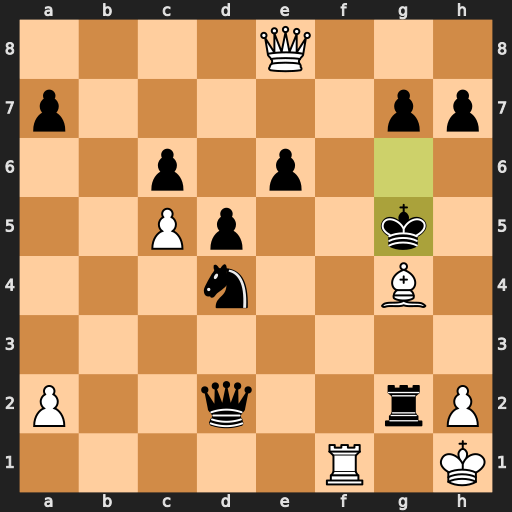

Generating zero-shot prediction for Task 2 (Move Prediction)...

--- RESULT ---
**Predicted Output:** Let's analyze the board.

The highlighted square is **g6** (light square, green background).

Looking at the pieces:

- White pawn on **h1**
- White pawn on **h2**
- White pawn on **h3** (not visible, but implied)
- White queen on **h1**
- White rook on **f1**
- White bishop on **d1**
- White knight on **f3**
- White king on **h1**
- Black pawn on **g7**
- Black pawn on **h7**
-
**Real Target (GT):**  Kg5
----------------------------------------------


       PROCESSING: TASK 3 (DUAL-IMAGE DELTA MOVE)
**Sample ID:** sample_000000
**Task Prompt:** 
You are a specialized model for chessboard temporal reasoning.
Your goal is to identify the move that transitioned the chessboard from State t to State t+1.
Input:
- Frame 1: Chessboard state at time t.
- Frame 2: Chessboard state at time t+1.
Output Format:
Return only the move in Standard Algebraic Notation (SAN).
**Ground Truth (Target):*

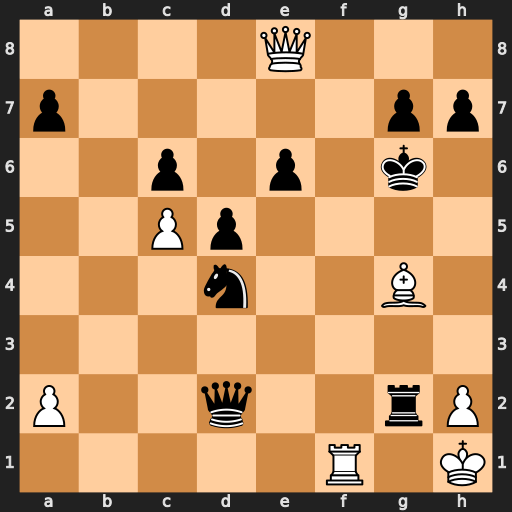

- Image 2 (End state):


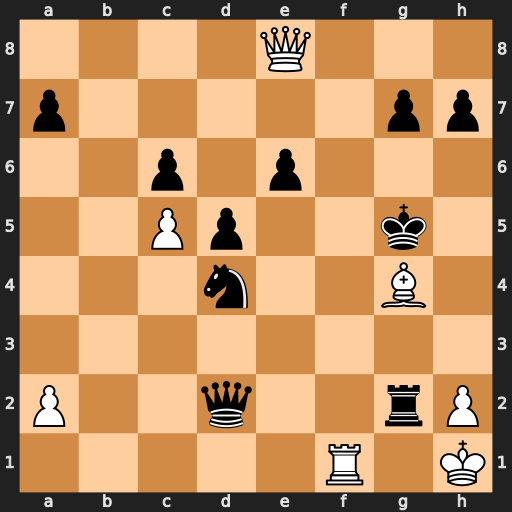

Generating zero-shot prediction for Task 3 (Dual-Image Delta Move)...

--- RESULT ---
**Predicted Output:** Let's analyze the board from both frames to find the move that transitioned it from t to t+1.

In **Frame 1**, the white king is on **h1** and the black king is on **h7**.

In **Frame 2**, the white king has moved to **h5**, and the black king has moved to **h7**.

This indicates that the white king moved from h1 to h5.

Therefore, the move is:

**h1-h5**
**Real Target (GT):**  Kg5
----------------------------------------------



In [20]:
import torch
from IPython.display import display, Image

# Dictionary of datasets for the 3 tasks
datasets = {
    "Task 1 (Image-to-FEN)": dataset_task1,
    "Task 2 (Move Prediction)": dataset_task2,
    "Task 3 (Dual-Image Delta Move)": dataset_task3
}

for task_name, dataset in datasets.items():
    print(f"\n==============================================")
    print(f"       PROCESSING: {task_name.upper()}")
    print(f"==============================================")

    # Grab the first test sample
    test_sample = dataset["test"][0]
    task_prompt = test_sample["prompt"]
    ground_truth = test_sample["target"]
    sample_id = test_sample["sample_id"]

    # Print textual input details
    print(f"**Sample ID:** {sample_id}")
    print(f"**Task Prompt:** \n{task_prompt}")
    print(f"**Ground Truth (Target):** {ground_truth}\n")

    # Handle visual inputs based on the task requirements
    if "Task 3" in task_name:
        # Task 3 requires two consecutive images (State t and State t+1)
        board_image_t0 = test_sample["image"]
        board_image_t1 = test_sample["image_t1"]

        print("**Visual Input:** Two board images (State t and State t+1)")
        print("- Image 1 (Start state):")
        display(board_image_t0)
        print("- Image 2 (End state):")
        display(board_image_t1)

        chat_messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": board_image_t0},
                    {"type": "image", "image": board_image_t1},
                    {"type": "text", "text": task_prompt},
                ]
            }
        ]
        model_images = [board_image_t0, board_image_t1]

    else:
        # Task 1 and Task 2 require a single board image
        board_image = test_sample["image"]

        print("**Visual Input:** Single board image")
        display(board_image)

        chat_messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": board_image},
                    {"type": "text", "text": task_prompt},
                ]
            }
        ]
        model_images = board_image

    # Apply the processor's chat template
    formatted_text = processor.apply_chat_template(
        chat_messages,
        tokenize=False,
        add_generation_prompt=True
    )

    # Tokenize inputs and move them to the GPU device
    model_inputs = processor(
        text=[formatted_text],
        images=model_images,
        padding=True,
        return_tensors="pt"
    ).to(model_vanilla.device)

    # Generate the zero-shot prediction
    print(f"Generating zero-shot prediction for {task_name}...")
    with torch.no_grad():
        output_token_ids = model_vanilla.generate(**model_inputs, max_new_tokens=128)

    # Trim prompt tokens from the generated output
    trimmed_output_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, output_token_ids)
    ]
    predicted_string = processor.batch_decode(
        trimmed_output_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]

    # Clean display of the results
    print(f"\n--- RESULT ---")
    print(f"**Predicted Output:** {predicted_string.strip()}")
    print(f"**Real Target (GT):**  {ground_truth.strip()}")
    print("-" * 46 + "\n")

Testing vanilla model on the whole dataset for the three tasks using the function *evaluate_chessboard_model_task* (1,2 and 3) defined in *src/eval/utilities.py*. The code is provided in three different notebook cells because of the very long time for execution.

**Task 1**

In [21]:
# Call the evaluation function for the vanilla model
vanilla_results_df, vanilla_summary_df = evaluate_chessboard_model_task_1(
    model=model_vanilla,
    processor=processor,
    dataset_split=dataset_task1["test"],
    model_name="Vanilla Qwen3.5-0.8B (Zero-Shot)"
)

# Initialize the global comparison DataFrame with the vanilla results
all_models_results_task1 = vanilla_summary_df

print("\nExample of results obtained form the evaluation:")
display(vanilla_results_df.head())

print("\nComparative Summary DataFrame (all_models_results):")
display(all_models_results_task1)

Evaluating Vanilla Qwen3.5-0.8B (Zero-Shot): 100%|██████████| 4/4 [00:14<00:00,  3.70s/it]


Evaluation completed for Vanilla Qwen3.5-0.8B (Zero-Shot)! Results saved to task1_vanilla_qwen3.5-0.8b_(zero-shot)_results.csv.

Example of results obtained form the evaluation:


,sample_id,ground_truth,predicted,fen_exact_match,levenshtein_distance,character_error_rate,square_by_square_accuracy
0,sample_000000,4Q3/p5pp/2p1p1k1/2Pp4/3n2B1/8/P2q2rP/5R1K b - ...,a1b2c3d4e5f6g7h8\n8h7g7e8\n7d6c5b4a3\n4e3d2c1b...,0.0,92,1.769231,0.0
1,sample_000001,3q1rk1/1p1bbppp/p3p3/1n1pP3/3N1P2/3QB2P/PPB3P1...,a1b2b3b4b5b6b7b8c8d8d9d9e9e1e1f1f2f3f4f5f6f7g7...,0.0,58,0.920635,0.0
2,sample_000002,8/2Kbk3/1B1p4/2pPp3/2B1Pp2/pP6/Pr3R2/8 w - - 1 51,a2 b2 c2 d2 e2 f2 g2 h2\na3 b3 c3 d3 e3 f3 g3 ...,0.0,133,2.714286,0.0
3,sample_000003,6k1/4bppp/2b1p3/1pNpP3/3P4/P3B3/r4PPP/2R3K1 w ...,a1b2b3b4b5b6b7b8c8d8e8f8g8h8,0.0,48,0.888889,0.0



Comparative Summary DataFrame (all_models_results):


,model_name,fen_exact_match,character_error_rate,square_by_square_accuracy,levenshtein_distance
0,Vanilla Qwen3.5-0.8B (Zero-Shot),0.0,1.57326,0.0,82.75


**Task 2**

In [22]:
# Call the evaluation function for the vanilla model
vanilla_results_df, vanilla_summary_df = evaluate_chessboard_model_task_2(
    model=model_vanilla,
    processor=processor,
    dataset_split=dataset_task2["test"],
    model_name="Vanilla Qwen3.5-0.8B (Zero-Shot)"
)

# Initialize the global comparison DataFrame with the vanilla results
all_models_results_task2 = vanilla_summary_df

print("\nExample of results obtained form the evaluation:")
display(vanilla_results_df.head())

print("\nComparative Summary DataFrame (all_models_results):")
display(all_models_results_task2)

Evaluating Vanilla Qwen3.5-0.8B (Zero-Shot) (Task 2): 100%|██████████| 4/4 [00:04<00:00,  1.00s/it]


Evaluation completed for Vanilla Qwen3.5-0.8B (Zero-Shot)! Results saved to task2_vanilla_qwen3.5-0.8b_(zero-shot)_results.csv.

Example of results obtained form the evaluation:


,sample_id,ground_truth,predicted,exact_match
0,sample_000000,Kg5,Let's analyze the board.\n\nThe highlighted sq...,0
1,sample_000001,Nxd4,The knight on c1 is in check. The only legal m...,0
2,sample_000002,Rxb2,"The piece at b2 is a white pawn, and the highl...",0
3,sample_000003,Nxe6,The knight at c1 is attacked by the pawn at f2...,0



Comparative Summary DataFrame (all_models_results):


,model_name,exact_match
0,Vanilla Qwen3.5-0.8B (Zero-Shot),0.0


**Task 3**

In [23]:
# Call the evaluation function for the vanilla model
vanilla_results_df, vanilla_summary_df = evaluate_chessboard_model_task_3(
    model=model_vanilla,
    processor=processor,
    dataset_split=dataset_task3["test"],
    model_name="Vanilla Qwen3.5-0.8B (Zero-Shot)"
)

# Initialize the global comparison DataFrame with the vanilla results
all_models_results_task3 = vanilla_summary_df

print("\nExample of results obtained form the evaluation:")
display(vanilla_results_df.head())

print("\nComparative Summary DataFrame (all_models_results):")
display(all_models_results_task3)

Evaluating Vanilla Qwen3.5-0.8B (Zero-Shot) on Task 3: 100%|██████████| 4/4 [00:13<00:00,  3.35s/it]


Evaluation completed for Vanilla Qwen3.5-0.8B (Zero-Shot) on Task 3! Results saved to task3_vanilla_qwen3.5-0.8b_(zero-shot)_results.csv.

Example of results obtained form the evaluation:


,sample_id,ground_truth,predicted,exact_match
0,sample_000000,Kg5,Let's analyze the board from both frames to fi...,0
1,sample_000001,Nxd4,The move is c1.,0
2,sample_000002,Rxb2,Let's analyze the board from both frames to fi...,0
3,sample_000003,Nxe6,The move is c2.,0



Comparative Summary DataFrame (all_models_results):


,model_name,exact_match
0,Vanilla Qwen3.5-0.8B (Zero-Shot),0.0


### Lora Finetuning - Patch Reordering

We'll define 4 different models using a different patch ordering to analyze the image. To reorder the image patches we can use the function **get_patch_reordering_indices()** defined in *src/eval/utilities.py*

TODO: Explanation of all the strategies

PS: raster is the default -> right ot left and top to bottom

In [24]:
strategies_to_train = ["raster", "zigzag", "spiral", "file_wise"]

for strat in strategies_to_train:
    order_map = get_patch_reordering_indices(strategy=strat)
    print(f"Strategy '{strat}' first 10 patch indices: {order_map[:10]}")

Strategy 'raster' first 10 patch indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Strategy 'zigzag' first 10 patch indices: [0, 1, 2, 3, 4, 5, 6, 7, 15, 14]
Strategy 'spiral' first 10 patch indices: [0, 1, 2, 3, 4, 5, 6, 7, 15, 23]
Strategy 'file_wise' first 10 patch indices: [0, 8, 16, 24, 32, 40, 48, 56, 1, 9]


Defining finetuning parameters:

In [25]:
peft_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_dropout=0.05,
    bias="none",
)

Using function **finetune_and_push_chessboard_model()** to finetune all the 4 models and push the obtained model on github. It is defined in *src/eval/utilities.py*.

Code is provided in 3 different cells (one for each task) due to the long execution time.

In [26]:
strategies_to_train = ["raster", "zigzag", "spiral", "file_wise"]
model_id = "Qwen/Qwen3.5-0.8B"

# You can modify this code to fine-tune only specific strategies or change the base model. For example:
# strategies_to_train = ["raster", "zigzag"]
# model_id = "Qwen/Qwen2.5-VL-7B-Instruct"

**Task 1**

In [27]:
# Dictionary to store trained models for Task 1
trained_reordered_models_task1 = {}

print("=== Starting Fine-Tuning Pipeline for Task 1 ===")

for strat in strategies_to_train:
    print(f"\nLoading fresh base model for Task 1 | Strategy: {strat}...")

    # Load a clean instance of the base model
    base_model = AutoModelForImageTextToText.from_pretrained(
        model_id,
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        device_map="auto"
    )

    # Train and push model for Task 1
    trained_reordered_models_task1[strat] = finetune_and_push_chessboard_model(
        strategy_name=strat,
        dataset=dataset_task1,
        processor=processor,
        model=base_model,
        peft_config=peft_config,
        task="task1",
        hf_org_prefix=ORGANIZATION_NAME,
    )

print("\nAll Task 1 models successfully trained and pushed!")

=== Starting Fine-Tuning Pipeline for Task 1 ===

Loading fresh base model for Task 1 | Strategy: raster...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]


Starting pipeline for TASK: TASK1 | STRATEGY: RASTER
Applying raster reordering to datasets for task1...


Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

...

  ...adapter_model.safetensors:  62%|######2   | 15.9MB / 25.6MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpsrmeycg0/tokenizer.json:  80%|#######9  | 16.0MB / 20.0MB            

Finished! Successfully uploaded to Hub: bdatm-project/qwen-task1-file_wise-lora

All Task 1 models successfully trained and pushed!


**Task 2**

In [29]:
# Dictionary to store trained models for Task 2
trained_reordered_models_task2 = {}

print("=== Starting Fine-Tuning Pipeline for Task 2 ===")

for strat in strategies_to_train:
    print(f"\nLoading fresh base model for Task 2 | Strategy: {strat}...")

    # Load a clean instance of the base model
    base_model = AutoModelForImageTextToText.from_pretrained(
        model_id,
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        device_map="auto"
    )

    # Train and push model for Task 2
    trained_reordered_models_task2[strat] = finetune_and_push_chessboard_model(
        strategy_name=strat,
        dataset=dataset_task2,
        processor=processor,
        model=base_model,
        peft_config=peft_config,
        task="task2",
        hf_org_prefix=ORGANIZATION_NAME,
    )

print("\nAll Task 2 models successfully trained and pushed!")

=== Starting Fine-Tuning Pipeline for Task 2 ===

Loading fresh base model for Task 2 | Strategy: raster...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]


Starting pipeline for TASK: TASK2 | STRATEGY: RASTER
Applying raster reordering to datasets for task2...
Preprocessing datasets...


Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Applying LoRA to the provided model...
Training model for task2 with raster reordering...


...

  ...adapter_model.safetensors:  62%|######2   | 15.9MB / 25.6MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp0dfvlz0m/tokenizer.json:  80%|#######9  | 16.0MB / 20.0MB            

Finished! Successfully uploaded to Hub: bdatm-project/qwen-task2-file_wise-lora

All Task 2 models successfully trained and pushed!


**Task 3**

In [30]:
# Dictionary to store trained models for Task 3
trained_reordered_models_task3 = {}

print("=== Starting Fine-Tuning Pipeline for Task 3 ===")

for strat in strategies_to_train:
    print(f"\nLoading fresh base model for Task 3 | Strategy: {strat}...")

    # Load a clean instance of the base model
    base_model = AutoModelForImageTextToText.from_pretrained(
        model_id,
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        device_map="auto"
    )

    # Train and push model for Task 3 (uses dual-image dataset)
    trained_reordered_models_task3[strat] = finetune_and_push_chessboard_model(
        strategy_name=strat,
        dataset=dataset_task3,
        processor=processor,
        model=base_model,
        peft_config=peft_config,
        task="task3",
        hf_org_prefix=ORGANIZATION_NAME,
    )

print("\nAll Task 3 models successfully trained and pushed!")

=== Starting Fine-Tuning Pipeline for Task 3 ===

Loading fresh base model for Task 3 | Strategy: raster...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]


Starting pipeline for TASK: TASK3 | STRATEGY: RASTER
Applying raster reordering to datasets for task3...


Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp058lbfb1/tokenizer.json:  80%|#######9  | 16.0MB / 20.0MB            

No files have been modified since last commit. Skipping to prevent empty commit.


Finished! Successfully uploaded to Hub: bdatm-project/qwen-task3-file_wise-lora

All Task 3 models successfully trained and pushed!


## Evaluation Lora Finetuned Models

We use the same approach as before to evaluate the new models using the function *evaluate_chessboard_model_task* (1,2 and 3) defined in *src/eval/utilities.py*.

As we did before, The code is provided in three different notebook cells (one for each task) because of the very long time for execution.

**Task 1**: Evaluation + pushing results to Hugging Face

In [31]:
print("=== Starting Evaluation Pipeline for Task 1 ===")

for strat in strategies_to_train:
    # Check if the specific strategy model is already available in memory
    if 'trained_reordered_models_task1' in locals() and strat in trained_reordered_models_task1 and trained_reordered_models_task1[strat] is not None:
        print(f"\n[IN-MEMORY] Using already trained model for strategy: {strat.upper()} (Task 1)...")
        model_to_eval = trained_reordered_models_task1[strat]
    else:
        # Fallback: Load from Hugging Face Hub if not present in memory
        print(f"\n[HF HUB] Model not found in memory. Loading from Hub for strategy: {strat.upper()} (Task 1)...")

        base_eval_model = AutoModelForImageTextToText.from_pretrained(
            model_id,
            torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
            device_map="auto"
        )
        repo_id_source = f"{ORGANIZATION_NAME}/qwen-task1-{strat}-lora"
        model_to_eval = PeftModel.from_pretrained(base_eval_model, repo_id_source)

    # Apply the specific patch reordering to the test split images for Task 1
    reordered_test_split = dataset_task1["test"].map(
        lambda sample: {
            "image": reorder_chessboard_image(sample["image"], strategy=strat, grid_size=8)
        }
    )

    # Run the evaluation utility function for Task 1
    strat_results_df, strat_summary_df = evaluate_chessboard_model_task_1(
        model=model_to_eval,
        processor=processor,
        dataset_split=reordered_test_split,
        model_name=f"Qwen + LoRA Task 1 ({strat.capitalize()} - SFT)"
    )

    # Append results to the Task 1 comparison DataFrame
    all_models_results_task1 = pd.concat([all_models_results_task1, strat_summary_df], ignore_index=True)

print("\n--- Final Comparative Summary Table for Task 1 ---")
display(all_models_results_task1)

=== Starting Evaluation Pipeline for Task 1 ===

[IN-MEMORY] Using already trained model for strategy: RASTER (Task 1)...


Map:   0%|          | 0/4 [00:00<?, ? examples/s]

Evaluating Qwen + LoRA Task 1 (Raster - SFT): 100%|██████████| 4/4 [00:20<00:00,  5.14s/it]


Evaluation completed for Qwen + LoRA Task 1 (Raster - SFT)! Results saved to task1_qwen_+_lora_task_1_(raster_-_sft)_results.csv.

[IN-MEMORY] Using already trained model for strategy: ZIGZAG (Task 1)...


Map:   0%|          | 0/4 [00:00<?, ? examples/s]

...


Evaluation completed for Qwen + LoRA Task 1 (Spiral - SFT)! Results saved to task1_qwen_+_lora_task_1_(spiral_-_sft)_results.csv.

[IN-MEMORY] Using already trained model for strategy: FILE_WISE (Task 1)...


Map:   0%|          | 0/4 [00:00<?, ? examples/s]

Evaluating Qwen + LoRA Task 1 (File_wise - SFT): 100%|██████████| 4/4 [00:31<00:00,  7.81s/it]


Evaluation completed for Qwen + LoRA Task 1 (File_wise - SFT)! Results saved to task1_qwen_+_lora_task_1_(file_wise_-_sft)_results.csv.

--- Final Comparative Summary Table for Task 1 ---


,model_name,fen_exact_match,character_error_rate,square_by_square_accuracy,levenshtein_distance
0,Vanilla Qwen3.5-0.8B (Zero-Shot),0.0,1.573260,0.0,82.75
1,Qwen + LoRA Task 1 (Raster - SFT),0.0,1.578068,0.0,83.00
2,Qwen + LoRA Task 1 (Zigzag - SFT),0.0,2.177147,0.0,117.75
3,Qwen + LoRA Task 1 (Spiral - SFT),0.0,2.236471,0.0,120.75
4,Qwen + LoRA Task 1 (File_wise - SFT),0.0,2.155242,0.0,119.50


In [32]:
hf_dataset_results_task1 = Dataset.from_pandas(all_models_results_task1)
repo_id_eval_task1 = f"{ORGANIZATION_NAME}/evaluation-results-task1"

print(f"Pushing Task 1 evaluation results to Hugging Face Hub: {repo_id_eval_task1}...")
hf_dataset_results_task1.push_to_hub(
    repo_id_eval_task1,
    private=False
)
print("Task 1 evaluation results successfully pushed to Hugging Face Hub!")

Pushing Task 1 evaluation results to Hugging Face Hub: bdatm-project/evaluation-results-task1...


Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /tmp/tmpqwiwuh2y.parquet    : 100%|##########| 3.13kB / 3.13kB            

Task 1 evaluation results successfully pushed to Hugging Face Hub!


**Task 2**: Evaluation + pushing results to Hugging Face


In [33]:
print("=== Starting Evaluation Pipeline for Task 2 ===")

for strat in strategies_to_train:
    # Check if the specific strategy model is already available in memory
    if 'trained_reordered_models_task2' in locals() and strat in trained_reordered_models_task2 and trained_reordered_models_task2[strat] is not None:
        print(f"\n[IN-MEMORY] Using already trained model for strategy: {strat.upper()} (Task 2)...")
        model_to_eval = trained_reordered_models_task2[strat]
    else:
        # Fallback: Load from Hugging Face Hub if not present in memory
        print(f"\n[HF HUB] Model not found in memory. Loading from Hub for strategy: {strat.upper()} (Task 2)...")

        base_eval_model = AutoModelForImageTextToText.from_pretrained(
            model_id,
            torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
            device_map="auto"
        )
        repo_id_source = f"{ORGANIZATION_NAME}/qwen-task2-{strat}-lora"
        model_to_eval = PeftModel.from_pretrained(base_eval_model, repo_id_source)

    # Apply the specific patch reordering to the test split images for Task 2
    reordered_test_split = dataset_task2["test"].map(
        lambda sample: {
            "image": reorder_chessboard_image(sample["image"], strategy=strat, grid_size=8)
        }
    )

    # Run the evaluation utility function for Task 2
    strat_results_df, strat_summary_df = evaluate_chessboard_model_task_2(
        model=model_to_eval,
        processor=processor,
        dataset_split=reordered_test_split,
        model_name=f"Qwen + LoRA Task 2 ({strat.capitalize()} - SFT)"
    )

    # Append results to the Task 2 comparison DataFrame
    all_models_results_task2 = pd.concat([all_models_results_task2, strat_summary_df], ignore_index=True)

print("\n--- Final Comparative Summary Table for Task 2 ---")
display(all_models_results_task2)

=== Starting Evaluation Pipeline for Task 2 ===

[IN-MEMORY] Using already trained model for strategy: RASTER (Task 2)...


Map:   0%|          | 0/4 [00:00<?, ? examples/s]


Evaluating Qwen + LoRA Task 2 (Raster - SFT) (Task 2):   0%|          | 0/4 [00:00<?, ?it/s]
Evaluating Qwen + LoRA Task 2 (Raster - SFT) (Task 2):  25%|██▌       | 1/4 [00:01<00:03,  1.29s/it]
Evaluating Qwen + LoRA Task 2 (Raster - SFT) (Task 2):  50%|█████     | 2/4 [00:02<00:02,  1.30s/it]
Evaluating Qwen + LoRA Task 2 (Raster - SFT) (Task 2):  75%|███████▌  | 3/4 [00:03<00:01,  1.30s/it]
Evaluating Qwen + LoRA Task 2 (Raster - SFT) (Task 2): 100%|██████████| 4/4 [00:05<00:00,  1.31s/it]


Evaluation completed for Qwen + LoRA Task 2 (Raster - SFT)! Results saved to task2_qwen_+_lora_task_2_(raster_-_sft)_results.csv.

[IN-MEMORY] Using already trained model for strategy: ZIGZAG (Task 2)...


Map:   0%|          | 0/4 [00:00<?, ? examples/s]

...


Evaluation completed for Qwen + LoRA Task 2 (Spiral - SFT)! Results saved to task2_qwen_+_lora_task_2_(spiral_-_sft)_results.csv.

[IN-MEMORY] Using already trained model for strategy: FILE_WISE (Task 2)...


Map:   0%|          | 0/4 [00:00<?, ? examples/s]


Evaluating Qwen + LoRA Task 2 (File_wise - SFT) (Task 2):   0%|          | 0/4 [00:00<?, ?it/s]
Evaluating Qwen + LoRA Task 2 (File_wise - SFT) (Task 2):  25%|██▌       | 1/4 [00:00<00:02,  1.20it/s]
Evaluating Qwen + LoRA Task 2 (File_wise - SFT) (Task 2):  50%|█████     | 2/4 [00:01<00:01,  1.07it/s]
Evaluating Qwen + LoRA Task 2 (File_wise - SFT) (Task 2):  75%|███████▌  | 3/4 [00:03<00:01,  1.11s/it]
Evaluating Qwen + LoRA Task 2 (File_wise - SFT) (Task 2): 100%|██████████| 4/4 [00:04<00:00,  1.11s/it]


Evaluation completed for Qwen + LoRA Task 2 (File_wise - SFT)! Results saved to task2_qwen_+_lora_task_2_(file_wise_-_sft)_results.csv.

--- Final Comparative Summary Table for Task 2 ---


,model_name,exact_match
0,Vanilla Qwen3.5-0.8B (Zero-Shot),0.0
1,Qwen + LoRA Task 2 (Raster - SFT),0.0
2,Qwen + LoRA Task 2 (Zigzag - SFT),0.0
3,Qwen + LoRA Task 2 (Spiral - SFT),0.0
4,Qwen + LoRA Task 2 (File_wise - SFT),0.0


In [34]:
hf_dataset_results_task2 = Dataset.from_pandas(all_models_results_task2)
repo_id_eval_task2 = f"{ORGANIZATION_NAME}/evaluation-results-task2"

print(f"Pushing Task 2 evaluation results to Hugging Face Hub: {repo_id_eval_task2}...")
hf_dataset_results_task2.push_to_hub(
    repo_id_eval_task2,
    private=False
)
print("Task 2 evaluation results successfully pushed to Hugging Face Hub!")

Pushing Task 2 evaluation results to Hugging Face Hub: bdatm-project/evaluation-results-task2...


Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /tmp/tmp567osvkd.parquet    : 100%|##########| 1.55kB / 1.55kB            

Task 2 evaluation results successfully pushed to Hugging Face Hub!


**Task 3** : Evaluation + pushing results to Hugging Face

In [35]:
print("=== Starting Evaluation Pipeline for Task 3 ===")

for strat in strategies_to_train:
    # Check if the specific strategy model is already available in memory
    if 'trained_reordered_models_task3' in locals() and strat in trained_reordered_models_task3 and trained_reordered_models_task3[strat] is not None:
        print(f"\n[IN-MEMORY] Using already trained model for strategy: {strat.upper()} (Task 3)...")
        model_to_eval = trained_reordered_models_task3[strat]
    else:
        # Fallback: Load from Hugging Face Hub if not present in memory
        print(f"\n[HF HUB] Model not found in memory. Loading from Hub for strategy: {strat.upper()} (Task 3)...")

        base_eval_model = AutoModelForImageTextToText.from_pretrained(
            model_id,
            torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
            device_map="auto"
        )
        repo_id_source = f"{ORGANIZATION_NAME}/qwen-task3-{strat}-lora"
        model_to_eval = PeftModel.from_pretrained(base_eval_model, repo_id_source)

    # Apply the specific patch reordering to both frames for Task 3[cite: 1]
    reordered_test_split = dataset_task3["test"].map(
        lambda sample: {
            "image": reorder_chessboard_image(sample["image"], strategy=strat, grid_size=8),
            "image_t1": reorder_chessboard_image(sample["image_t1"], strategy=strat, grid_size=8)
        }
    )

    # Run the evaluation utility function for Task 3
    strat_results_df, strat_summary_df = evaluate_chessboard_model_task_3(
        model=model_to_eval,
        processor=processor,
        dataset_split=reordered_test_split,
        model_name=f"Qwen + LoRA Task 3 ({strat.capitalize()} - SFT)"
    )

    # Append results to the Task 3 comparison DataFrame
    all_models_results_task3 = pd.concat([all_models_results_task3, strat_summary_df], ignore_index=True)

print("\n--- Final Comparative Summary Table for Task 3 ---")
display(all_models_results_task3)

=== Starting Evaluation Pipeline for Task 3 ===

[IN-MEMORY] Using already trained model for strategy: RASTER (Task 3)...


Map:   0%|          | 0/4 [00:00<?, ? examples/s]



Evaluating Qwen + LoRA Task 3 (Raster - SFT) on Task 3:   0%|          | 0/4 [00:00<?, ?it/s]

Evaluating Qwen + LoRA Task 3 (Raster - SFT) on Task 3:  25%|██▌       | 1/4 [00:00<00:02,  1.15it/s]

Evaluating Qwen + LoRA Task 3 (Raster - SFT) on Task 3:  50%|█████     | 2/4 [00:01<00:01,  1.15it/s]

Evaluating Qwen + LoRA Task 3 (Raster - SFT) on Task 3:  75%|███████▌  | 3/4 [00:10<00:04,  4.50s/it]

Evaluating Qwen + LoRA Task 3 (Raster - SFT) on Task 3: 100%|██████████| 4/4 [00:11<00:00,  2.86s/it]


Evaluation completed for Qwen + LoRA Task 3 (Raster - SFT) on Task 3! Results saved to task3_qwen_+_lora_task_3_(raster_-_sft)_results.csv.

[IN-MEMORY] Using already trained model for strategy: ZIGZAG (Task 3)...


Map:   0%|          | 0/4 [00:00<?, ? examples/s]

...


Evaluation completed for Qwen + LoRA Task 3 (Spiral - SFT) on Task 3! Results saved to task3_qwen_+_lora_task_3_(spiral_-_sft)_results.csv.

[IN-MEMORY] Using already trained model for strategy: FILE_WISE (Task 3)...


Map:   0%|          | 0/4 [00:00<?, ? examples/s]

Evaluating Qwen + LoRA Task 3 (File_wise - SFT) on Task 3: 100%|██████████| 4/4 [00:03<00:00,  1.15it/s]


Evaluation completed for Qwen + LoRA Task 3 (File_wise - SFT) on Task 3! Results saved to task3_qwen_+_lora_task_3_(file_wise_-_sft)_results.csv.

--- Final Comparative Summary Table for Task 3 ---


,model_name,exact_match
0,Vanilla Qwen3.5-0.8B (Zero-Shot),0.0
1,Qwen + LoRA Task 3 (Raster - SFT),0.0
2,Qwen + LoRA Task 3 (Zigzag - SFT),0.0
3,Qwen + LoRA Task 3 (Spiral - SFT),0.0
4,Qwen + LoRA Task 3 (File_wise - SFT),0.0


In [36]:
hf_dataset_results_task3 = Dataset.from_pandas(all_models_results_task3)
repo_id_eval_task3 = f"{ORGANIZATION_NAME}/evaluation-results-task3"

print(f"Pushing Task 3 evaluation results to Hugging Face Hub: {repo_id_eval_task3}...")
hf_dataset_results_task3.push_to_hub(
    repo_id_eval_task3,
    private=False
)
print("Task 3 evaluation results successfully pushed to Hugging Face Hub!")

Pushing Task 3 evaluation results to Hugging Face Hub: bdatm-project/evaluation-results-task3...


Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /tmp/tmp3h9c7bmj.parquet    : 100%|##########| 1.55kB / 1.55kB            

Task 3 evaluation results successfully pushed to Hugging Face Hub!


## Results and Final Considerations

Load the results of the finetuning and evaluation from Hugging Face

In [37]:
# Dictionary to store the downloaded results DataFrames
downloaded_eval_results = {}

print("=== Downloading Evaluation Results for All Tasks ===")

for task in tasks:
    # Repo ID
    repo_id_eval = f"{ORGANIZATION_NAME}/evaluation-results-{task}"
    print(f"Downloading {task.upper()} from: {repo_id_eval}...")

    # Load dataset from Hugging Face and convert it to a pandas DataFrame
    downloaded_eval_results[task] = load_dataset(repo_id_eval, split="train").to_pandas()

print("\nAll evaluation results successfully downloaded and loaded into 'downloaded_eval_results'!")

=== Downloading Evaluation Results for All Tasks ===


README.md:   0%|          | 0.00/466 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.13kB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5 [00:00<?, ? examples/s]

...

README.md:   0%|          | 0.00/307 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.55kB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5 [00:00<?, ? examples/s]


All evaluation results successfully downloaded and loaded into 'downloaded_eval_results'!


**task 1**: Displaying results sorted by **character_error_rate**

In [38]:
print("\n--- TASK 1 Comparative Summary Table (Ordered from Best to Worst by CER) ---")

sorted_results_task1 = downloaded_eval_results["task1"].sort_values(by="character_error_rate", ascending=True).reset_index(drop=True)
display(sorted_results_task1)


--- TASK 1 Comparative Summary Table (Ordered from Best to Worst by CER) ---


,model_name,fen_exact_match,character_error_rate,square_by_square_accuracy,levenshtein_distance
0,Vanilla Qwen3.5-0.8B (Zero-Shot),0.0,1.573260,0.0,82.75
1,Qwen + LoRA Task 1 (Raster - SFT),0.0,1.578068,0.0,83.00
2,Qwen + LoRA Task 1 (File_wise - SFT),0.0,2.155242,0.0,119.50
3,Qwen + LoRA Task 1 (Zigzag - SFT),0.0,2.177147,0.0,117.75
4,Qwen + LoRA Task 1 (Spiral - SFT),0.0,2.236471,0.0,120.75


**task 2**: Displaying Results sorted by **Exact Match**

In [39]:
print("\n--- TASK 2 Comparative Summary Table (Ordered from Best to Worst by Exact Match) ---")

sorted_results_task2 = downloaded_eval_results["task2"].sort_values(by="exact_match", ascending=False).reset_index(drop=True)
display(sorted_results_task2)


--- TASK 2 Comparative Summary Table (Ordered from Best to Worst by Exact Match) ---


,model_name,exact_match
0,Vanilla Qwen3.5-0.8B (Zero-Shot),0.0
1,Qwen + LoRA Task 2 (Raster - SFT),0.0
2,Qwen + LoRA Task 2 (Zigzag - SFT),0.0
3,Qwen + LoRA Task 2 (Spiral - SFT),0.0
4,Qwen + LoRA Task 2 (File_wise - SFT),0.0


**task 3**: Displaying Results sorted by **Exact Match**

In [40]:
print("\n--- TASK 3 Comparative Summary Table (Ordered from Best to Worst by Exact Match) ---")

sorted_results_task3 = downloaded_eval_results["task3"].sort_values(by="exact_match", ascending=False).reset_index(drop=True)
display(sorted_results_task3)


--- TASK 3 Comparative Summary Table (Ordered from Best to Worst by Exact Match) ---


,model_name,exact_match
0,Vanilla Qwen3.5-0.8B (Zero-Shot),0.0
1,Qwen + LoRA Task 3 (Raster - SFT),0.0
2,Qwen + LoRA Task 3 (Zigzag - SFT),0.0
3,Qwen + LoRA Task 3 (Spiral - SFT),0.0
4,Qwen + LoRA Task 3 (File_wise - SFT),0.0


### Final Considerations

TODO